# Aplicación a *Plasmodium falciparum*

Embudo de compuestos huérfanos con actividad fenotípica contra *P. falciparum* y
propuesta de blancos para los que el método puede tratar:

  1. compuestos con bioactividad fenotípica positiva contra `pfal`;
  2. de esos, los que **no** tienen ningún enlace de bioactividad a un blanco
     proteico (huérfanos en el sentido del paper);
  3. de esos, los tratables: con al menos un vecino químico con blanco conocido.

Para cada tratable se arma la semilla con su vecindario y se propaga; se conservan
las proteínas con `rG ≤ r*G`, el corte estimado en el notebook `03`.

Fuente: `reproducir_v6/aplicacion_pfal/`.
Salidas: `04_pfal_embudo.csv`, `04_pfal_compuestos.csv`, `04_pfal_sugerencias.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/huerfanas")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "04"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out')

## Datos

In [2]:
# cluster_consistent=True: `huerfanas/` filtra los positivos/negativos
# inconsistentes a nivel cluster, como orphan_drugs_v4.ipynb.
crudo = tdr.cargar_db(anotaciones=True, quimica=True, fenotipo=True, cluster_consistent=True)

# README §7.3: el filtro de promiscuidad se APLICA antes de armar ninguna semilla.
# La lista sale de analiceDB/03; si falta, el error dice qué correr.
promiscuos = tdr.compuestos_promiscuos()
datos = tdr.filtrar_capa_quimica(crudo, promiscuos)

HUERFANAS = tdr.out("huerfanas")
rg_star = float(pd.read_csv(HUERFANAS / "03_rg_estrella.csv")["r_g_estrella"].iloc[0])
optimos = fh.parametros_optimos()
print(f"corte r*G = {rg_star:.0f}  ·  parámetros de sp{tdr.SP_FOCO}: {optimos[tdr.SP_FOCO]}")

· 00_specie_target
· 03_bioactivities_target_compound
· 04a_interpro / 04b_orthomcl
· 01/02 clusters y aristas quimicas (pesado)
· 03_bioactivities_organism_compound
filtro de promiscuidad (MW < 150 y N_parentales > 100): 25 compuestos
  sclus 2396103 -> 2396078 (0.00 % removido)
  dds   973 -> 973 (0.00 % removido)
corte r*G = 54  ·  parámetros de pfal: (1.2, 1.0, 1.0, 0.8)


## Acondicionamiento

                               paso   n
        1 - fenotípicamente activos 233
2 - sin blanco proteico (huérfanos)  32
        3 - tratables por el método  12
  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/04_f01_embudo.pdf


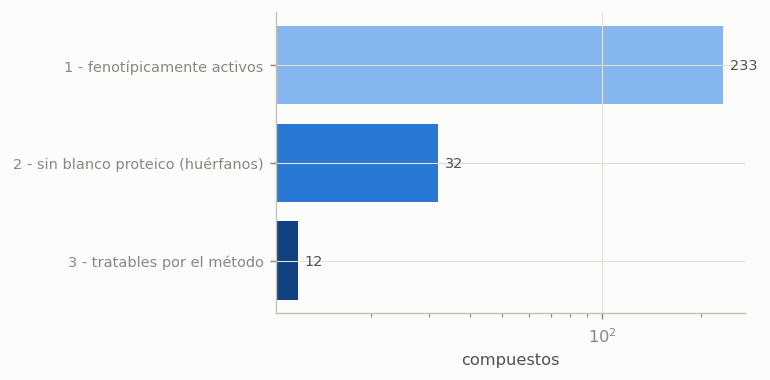

In [ ]:
SP = tdr.SP_FOCO   # protozoo parásito; ver tdr.SPECIES
embudo, compuestos = fh.embudo_pfal(datos, sp=SP)
tratables = compuestos.loc[compuestos["tratable"], "drug_id"].values
print(embudo.to_string(index=False))

fig = fh.fig_embudo(embudo, plt)
tdr.guardar(fig, f"{N
B}_f01_embudo", FIGURAS)

## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
ctx = fh.preparar_especie(datos, SP, optimos[SP], pd.DataFrame({"sp_id": []}))
posdt_sp = datos.posdt.merge(datos.st[["target_id", "sp_id"]], on="target_id", how="left")
fh.fijar_contexto(datos, posdt_sp, ctx)

sugerencias = []
for cid in tratables:
    seed = fh.semilla_de_droga(datos, cid, datos.posdt[["drug_id", "target_id"]],
                               consolidar=True)
    if seed is None or seed.empty:
        continue
    rnk = tdr.propagar(datos.sta, seed, ctx["cat_rs"], beta=ctx["beta"],
                       lambda_=ctx["lambda_"], gamma=ctx["gamma"])
    rnk["rG"] = rnk["score"].rank(ascending=False, method="average")
    top = rnk[(rnk["rG"] <= rg_star) & rnk["target_id"].astype(str).isin(ctx["sp_targets"])]
    sugerencias.append(top.assign(drug_id=cid))

sug = pd.concat(sugerencias, ignore_index=True) if sugerencias else pd.DataFrame()
embudo.to_csv(SALIDAS / f"{NB}_pfal_embudo.csv", index=False)
compuestos.to_csv(SALIDAS / f"{NB}_pfal_compuestos.csv", index=False)
sug.to_csv(SALIDAS / f"{NB}_pfal_sugerencias.csv", index=False)
fh.escribir_meta(SALIDAS, NB, notebook="04_aplicacion_pfal.ipynb",
                 params={"especie": SP, "r_g_estrella": rg_star, "optimos": optimos[SP]},
                 n_core=n_core, filtro_promiscuidad=True)

  meta -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/04_meta.json


{'notebook': '04_aplicacion_pfal.ipynb',
 'nb': '04',
 'fecha': '2026-09-07 13:47',
 'params': {'especie': 'pfal',
  'r_g_estrella': 54.0,
  'optimos': [1.2, 1.0, 1.0, 0.8]},
 'n_core': 20,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'filtro_promiscuidad': True}

# Resultados

In [5]:
embudo     = pd.read_csv(SALIDAS / f"{NB}_pfal_embudo.csv")
compuestos = pd.read_csv(SALIDAS / f"{NB}_pfal_compuestos.csv")
sug        = pd.read_csv(SALIDAS / f"{NB}_pfal_sugerencias.csv")
print(f"{sug['drug_id'].nunique()} compuestos con sugerencias, "
      f"{sug['target_id'].nunique()} blancos propuestos")
sug.head(20)

1 compuestos con sugerencias, 2 blancos propuestos


,target_id,score,rG,drug_id
0,Q8IK11,0.011478,15.5,560020
1,Q8I242,0.011478,15.5,560020


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/04_f02_rg_sugerencias.pdf


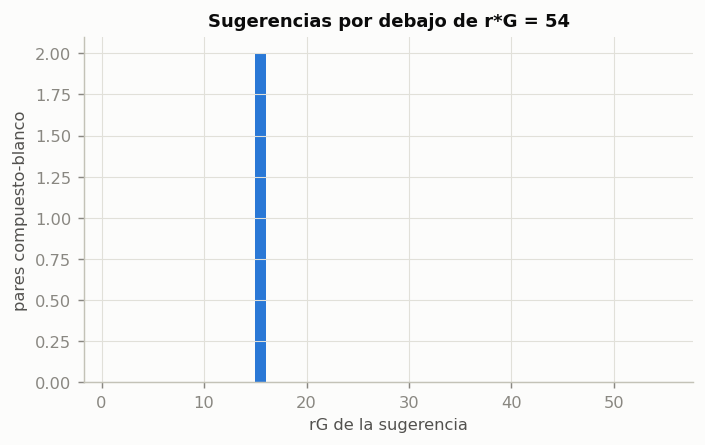

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5), tight_layout=True)
ax.hist(sug["rG"], bins=np.arange(1, rg_star + 2), color=tdr.S1)
ax.set_xlabel("rG de la sugerencia")
ax.set_ylabel("pares compuesto-blanco")
ax.set_title(f"Sugerencias por debajo de r*G = {rg_star:.0f}")
tdr.guardar(fig, f"{NB}_f02_rg_sugerencias", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/04_f03_familias.pdf


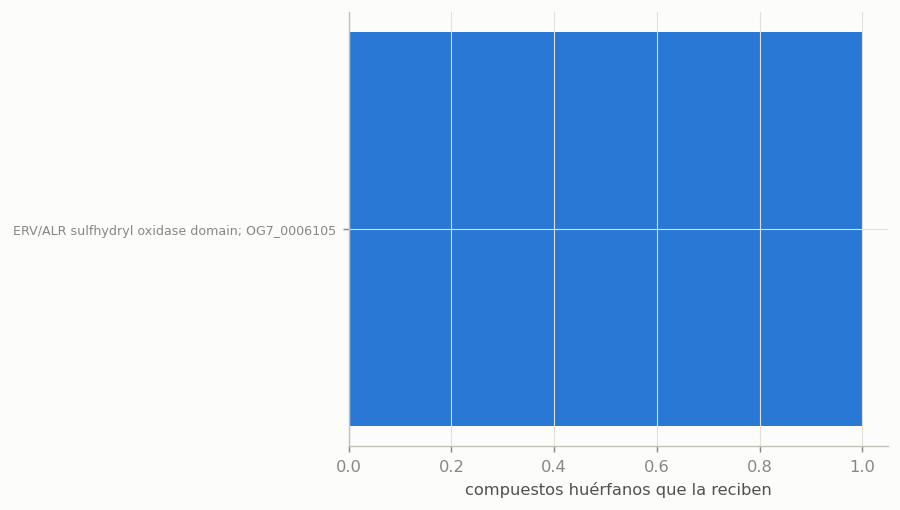

In [7]:
# Familias de blancos más sugeridas: los casos de estudio del paper (Figs 5, 7, 8)
familias = tdr.anotar_targets(sug["target_id"].unique(), datos.sta)
top = (sug.merge(familias, on="target_id", how="left")
       .groupby("anotaciones")["drug_id"].nunique()
       .sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
ax.barh(range(len(top)), top.values, color=tdr.S1)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([t[:60] for t in top.index], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("compuestos huérfanos que la reciben")
tdr.guardar(fig, f"{NB}_f03_familias", FIGURAS)